Dynesty

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dynesty import NestedSampler
from astropy.cosmology import FlatLambdaCDM, wCDM, w0waCDM, LambdaCDM
from scipy import special
MB=-19.3
# =========================
# LOAD DATA
# =========================
data = pd.read_csv(
    "/Users/krp_21/Downloads/Data Analysis Project/DataRelease-main/Pantheon+_Data/4_DISTANCES_AND_COVAR/Pantheon+SH0ES.dat",
    sep=r'\s+'
)

z = data["zHD"].values
mbcorr = data["m_b_corr"].values
is_cal = data["IS_CALIBRATOR"].astype(bool).values
cephdist = data["CEPH_DIST"].values

mask = (z > 0.01) | is_cal
z = z[mask]
mbcorr = mbcorr[mask]
is_cal = is_cal[mask]
cephdist = cephdist[mask]

N = len(z)

# =========================
# COVARIANCE
# =========================
cov_raw = np.loadtxt(
    "/Users/krp_21/Downloads/Data Analysis Project/DataRelease-main/Pantheon+_Data/4_DISTANCES_AND_COVAR/Pantheon+SH0ES_STAT+SYS.cov"
)

N_full = int(cov_raw[0])
cov_full = cov_raw[1:].reshape((N_full, N_full))

indices = np.where(mask)[0]
cov = cov_full[np.ix_(indices, indices)]

#cov += 1e-8 * np.eye(len(cov))

signC, logdetC = np.linalg.slogdet(cov)

# =========================
# MODELS
# =========================
models = ["wCDM", "CPL"]

# =========================
# MODEL FUNCTION
# =========================
from scipy.integrate import quad

c = 299792.458  # km/s

# =========================
# H(z) DEFINITIONS
# =========================

def H_LCDM(z, H0, Om):
    val = Om*(1+z)**3 + (1-Om)
    if val <= 0:
        return None
    return H0 * np.sqrt(val)

def H_wCDM(z, H0, Om, w):
    val = Om*(1+z)**3 + (1-Om)*(1+z)**(3*(1+w))
    if val <= 0:
        return None
    return H0 * np.sqrt(val)

def H_CPL(z, H0, Om, w0, wa):
    val = Om*(1+z)**3 + (1-Om)*(1+z)**(3*(1+w0+wa)) * np.exp(-3*wa*z/(1+z))
    if val <= 0:
        return None
    return H0 * np.sqrt(val)

def H_nonflat(z, H0, Om, Ol):
    Ok = 1 - Om - Ol
    val = Om*(1+z)**3 + Ok*(1+z)**2 + Ol
    if val <= 0:
        return None
    return H0 * np.sqrt(val)


# =========================
# DISTANCE MODULUS
# =========================

def mu_model(theta, model):

    try:

        if model == "LCDM":
            H0, Om = theta
            H_func = lambda zp: H_LCDM(zp, H0, Om)

        elif model == "wCDM":
            H0, Om, w = theta
            H_func = lambda zp: H_wCDM(zp, H0, Om, w)

        elif model == "CPL":
            H0, Om, w0, wa = theta
            H_func = lambda zp: H_CPL(zp, H0, Om, w0, wa)

        elif model == "nonflat":
            H0, Om, Ol = theta
            H_func = lambda zp: H_nonflat(zp, H0, Om, Ol)

        else:
            return None

        DL = []

        for zi in z:

            integral, _ = quad(lambda zp: c / H_func(zp), 0, zi)

            if not np.isfinite(integral):
                return None

            DL.append((1 + zi) * integral)

        DL = np.array(DL)

        if np.any(DL <= 0):
            return None

        mu = 5*np.log10(DL) + 25

        return mu

    except:
        return None


# =========================
# GAUSSIAN
# =========================
def loglike_gaussian(theta, model):
    try:
        m = mu_model(theta, model)
    except:
        return -1e100

    hr1 = mbcorr - m
    hr2 = mbcorr - cephdist
    r = (hr1 * (~is_cal).astype(float) + hr2 * (is_cal).astype(float)) - MB

    Q = r @ np.linalg.solve(cov, r)

    return -0.5 * (Q + logdetC + N*np.log(2*np.pi))


# =========================
# STUDENT-T
# =========================
def loglike_student(theta, model):

    *base, nu = theta

    if nu <= 2:
        return -1e100

    try:
        m = mu_model(base, model)
    except:
        return -1e100

    hr1 = mbcorr - m
    hr2 = mbcorr - cephdist



    r = (hr1 * (~is_cal).astype(float) + hr2 * (is_cal).astype(float)) - MB

    # --- Correct scaling ---
    Sigma = ((nu - 2)/nu) * cov

    # --- Stable quadratic form ---
    Q = r @ np.linalg.solve(Sigma, r)

    # --- log determinant ---
    signS, logdetS = np.linalg.slogdet(Sigma)
    if signS <= 0:
        return -1e100

    logL = (
        special.loggamma((nu+N)/2)
        - special.loggamma(nu/2)
        - (N/2)*np.log(nu*np.pi)
        - 0.5*logdetS
        - ((nu+N)/2)*np.log(1 + Q/nu)
    )

    return logL

# =========================
# PRIORS
# =========================
def prior_LCDM(u):
    return np.array([50+50*u[0], u[1]])

def prior_wCDM(u):
    return np.array([50+50*u[0], u[1], -2+4*u[2]])

def prior_CPL(u):
    return np.array([50+50*u[0], u[1], -2+4*u[2], -2+4*u[3]])

def prior_nonflat(u):
    return np.array([50+50*u[0], u[1], u[2]])

prior_dict = {
    "LCDM": prior_LCDM,
    "wCDM": prior_wCDM,
    "CPL": prior_CPL,
    "nonflat": prior_nonflat
}

ndim_dict = {
    "LCDM": 2,
    "wCDM": 3,
    "CPL": 4,
    "nonflat": 3
}

# ν prior
def add_nu_prior(theta, u_last):
    log_nu = np.log(2) + u_last*(np.log(1e6)-np.log(2))
    return np.append(theta, np.exp(log_nu))


# =========================
# RUN ALL
# =========================
results = {}
nu_samples = {}

for model in models:

    print(f"\nRunning {model}...")

    prior_base = prior_dict[model]
    ndim_base = ndim_dict[model]
    
    sampler_g = NestedSampler(
        lambda th: loglike_gaussian(th, model),
        prior_base,
        ndim_base,
        nlive=200
    )
    sampler_g.run_nested()
    logZ_g = sampler_g.results.logz[-1]

    def prior_student(u):
        base = prior_base(u[:-1])
        return add_nu_prior(base, u[-1])

    sampler_t = NestedSampler(
        lambda th: loglike_student(th, model),
        prior_student,
        ndim_base+1,
        nlive=200
    )
    sampler_t.run_nested()
    logZ_t = sampler_t.results.logz[-1]

    # store
    results[(model, "Gaussian")] = logZ_g
    results[(model, "Student-t")] = logZ_t

    # store ν posterior
    samples = sampler_t.results.samples
    weights = np.exp(sampler_t.results.logwt - sampler_t.results.logz[-1])
    nu_samples[model] = (samples[:, -1], weights)

print("\n===== ΔlogZ TABLE =====")

for model in models:
    dlogZ = results[(model, "Student-t")] - results[(model, "Gaussian")]
    print(f"{model}: ΔlogZ = {dlogZ:.3f}")

plt.figure(figsize=(7,5))

for model in models:
    nu, w = nu_samples[model]
    plt.hist(nu, bins=50, weights=w, density=True, alpha=0.5, label=model)

plt.xscale("log")
plt.xlabel(r"$\nu$", fontsize=14)
plt.ylabel("Posterior Density", fontsize=14)
plt.title("Posterior of ν (Student-t)", fontsize=15)
plt.legend()
plt.show()

print("\n===== INTERPRETATION =====")

for model in models:
    dlogZ = results[(model, "Student-t")] - results[(model, "Gaussian")]

    if dlogZ > 5:
        print(f"{model}: Strong evidence for non-Gaussianity (Student-t preferred)")
    elif dlogZ > 2:
        print(f"{model}: Moderate evidence for non-Gaussianity")
    else:
        print(f"{model}: Gaussian likely sufficient")


Running wCDM...


2437it [25:56,  1.57it/s, +200 | bound: 30 | nc: 1 | ncall: 13579 | eff(%): 19.710 | loglstar:   -inf < 895.399 <    inf | logz: 884.874 +/-  0.216 | dlogz:  0.001 >  0.209]
2778it [1:12:05,  1.56s/it, +200 | bound: 54 | nc: 1 | ncall: 18378 | eff(%): 16.382 | loglstar:   -inf < 900.285 <    inf | logz: 888.036 +/-  0.233 | dlogz:  0.001 >  0.209]



Running CPL...


384it [01:59,  1.35s/it, bound: 0 | nc: 22 | ncall: 1374 | eff(%): 27.948 | loglstar:   -inf < -464.233 <    inf | logz: -472.140 +/-  0.199 | dlogz: 1393.616 >  0.209]  

MCMC Sampling

Number of supernovae used: 1657
Fixed MB: -19.3
Covariance matrix shape: (1657, 1657)

Running: Flat_LCDM | Gaussian
Initial guess: [71.6   0.33]
Initial log posterior: 895.1433405818891
Minimizer success: True
Best fit: [71.68234292  0.32894392]
Best log posterior: 895.3094680062825


100%|███████████████████████████████████████| 5000/5000 [04:53<00:00, 17.01it/s]


Mean acceptance fraction: 0.715875


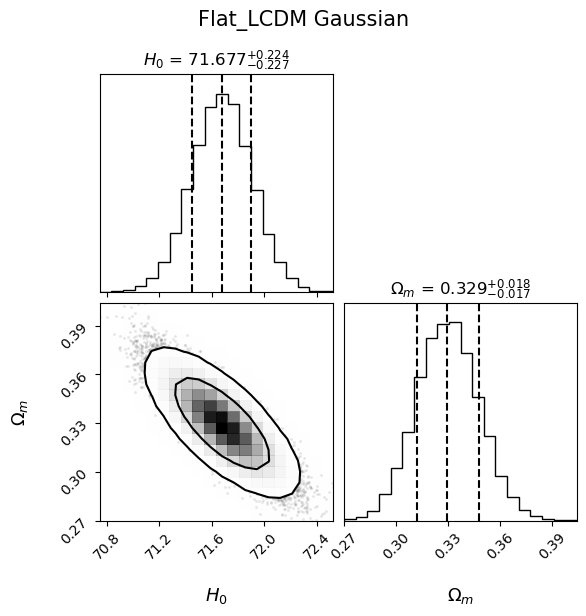


Running: Flat_LCDM | Student's t
Initial guess: [71.6   0.33 30.  ]
Initial log posterior: 896.2956001683971
Minimizer success: True
Best fit: [71.68234295  0.32894391  4.46764115]
Best log posterior: 897.2327295235373


100%|███████████████████████████████████████| 5000/5000 [04:08<00:00, 20.10it/s]


Mean acceptance fraction: 0.554140625


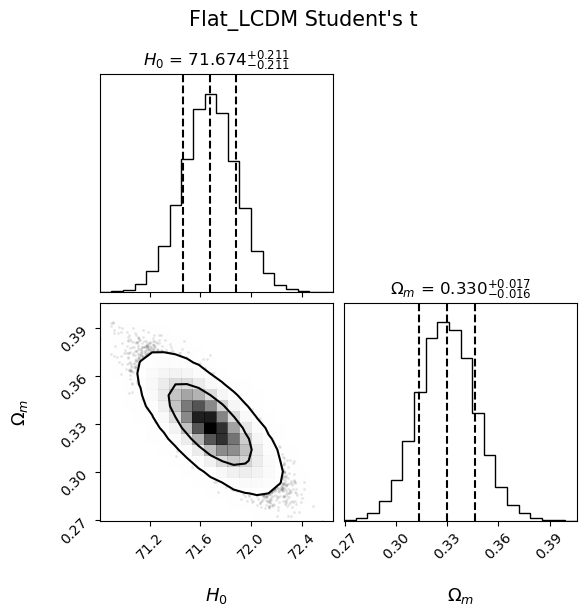


Running: LCDM | Gaussian
Initial guess: [71.6  0.3  0. ]
Initial log posterior: 888.932971184862
Minimizer success: True
Best fit: [7.16155321e+01 3.07074738e-01 5.53020874e-02]
Best log posterior: 895.4041336866942


100%|███████████████████████████████████████| 5000/5000 [04:59<00:00, 16.67it/s]


Mean acceptance fraction: 0.646846875


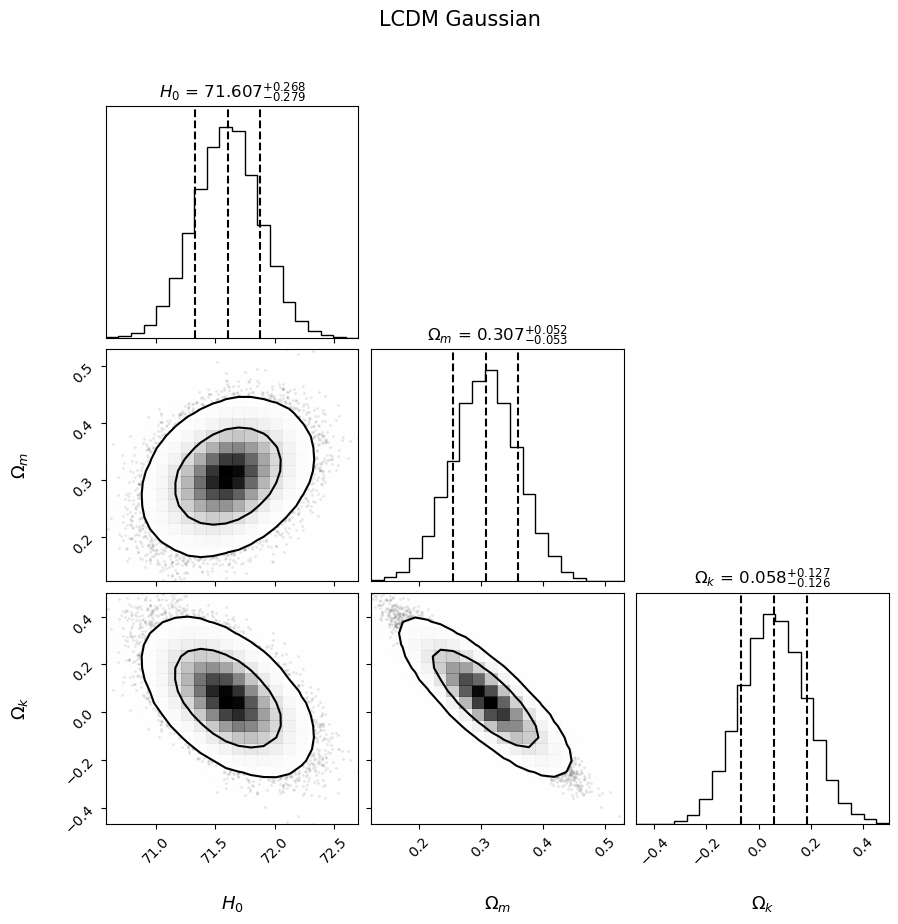


Running: LCDM | Student's t
Initial guess: [71.6  0.3  0.  30. ]
Initial log posterior: 889.2676442812245
Minimizer success: True
Best fit: [7.16155325e+01 3.07074775e-01 5.53019690e-02 4.46746637e+00]
Best log posterior: 897.340562820543


100%|███████████████████████████████████████| 5000/5000 [04:10<00:00, 19.99it/s]


Mean acceptance fraction: 0.5088781250000001


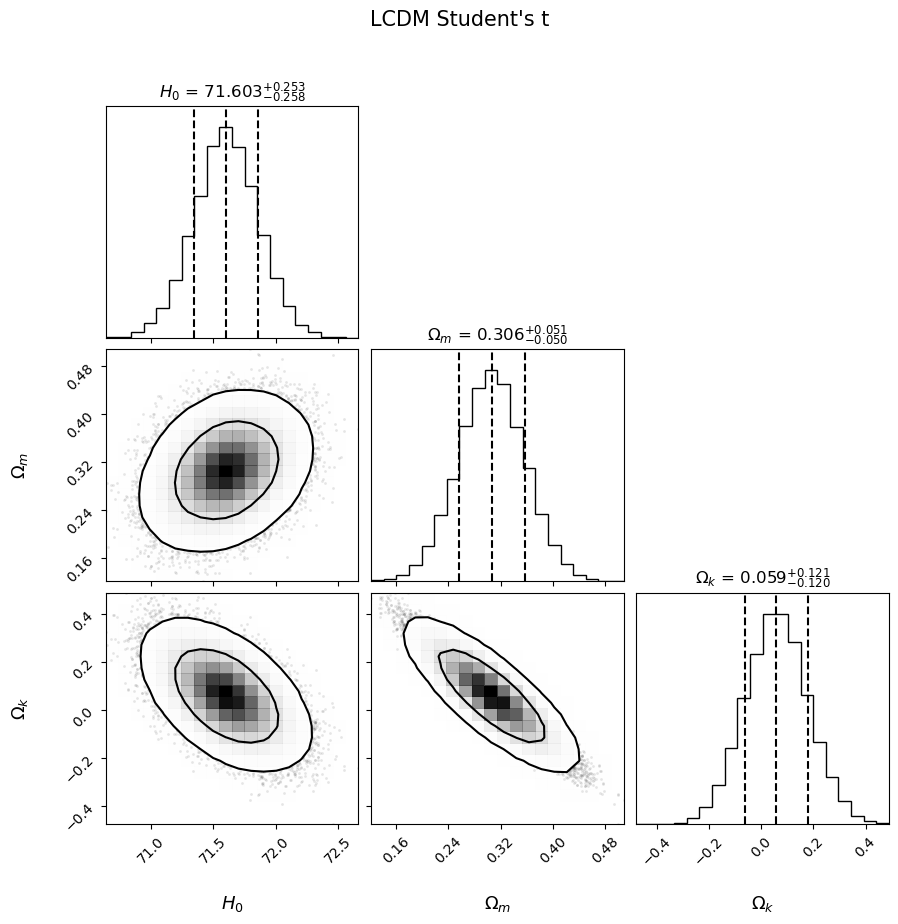


Running: wCDM | Gaussian
Initial guess: [71.6   0.32 -1.  ]
Initial log posterior: 894.1593359670094
Minimizer success: True
Best fit: [71.60010149  0.30244597 -0.93264967]
Best log posterior: 895.4040745067898


100%|███████████████████████████████████████| 8000/8000 [10:16<00:00, 12.98it/s]


Mean acceptance fraction: 0.5939484375


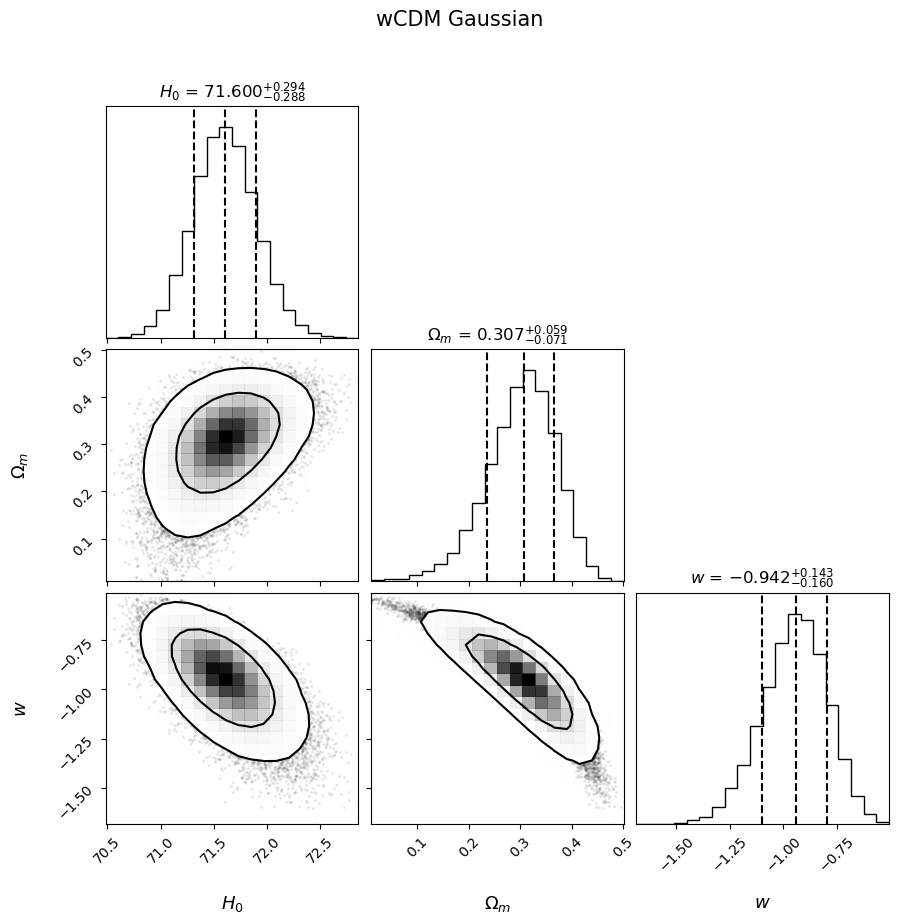


Running: wCDM | Student's t
Initial guess: [71.6   0.32 -1.   30.  ]
Initial log posterior: 895.1781413476089
Minimizer success: True
Best fit: [71.60010186  0.30244596 -0.9326497   4.46745977]
Best log posterior: 897.340495404578


100%|███████████████████████████████████████| 8000/8000 [08:39<00:00, 15.39it/s]


Mean acceptance fraction: 0.47177187500000006


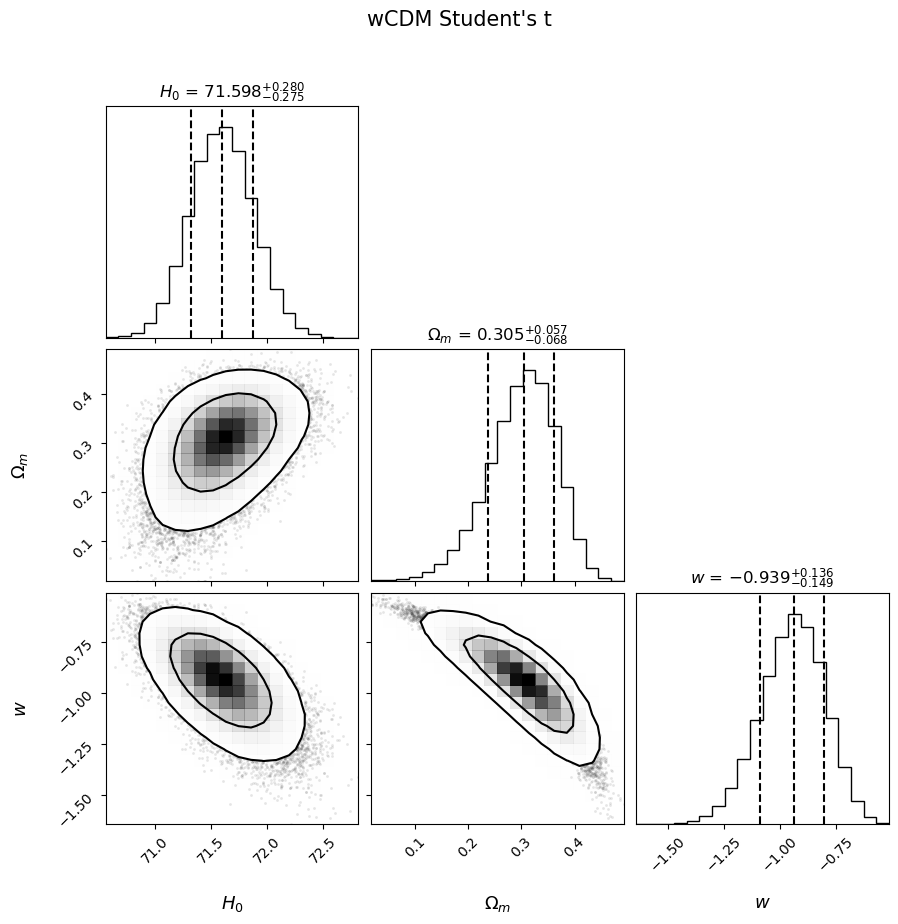


Running: CPL | Gaussian
Initial guess: [71.6   0.32 -1.    0.  ]
Initial log posterior: 894.1593359670094
Minimizer success: True
Best fit: [ 7.16009996e+01  3.01531128e-01 -9.31965732e-01  9.32073212e-03]
Best log posterior: 895.4040828255995


100%|█████████████████████████████████████| 10000/10000 [13:56<00:00, 11.95it/s]


Mean acceptance fraction: 0.45084583333333333


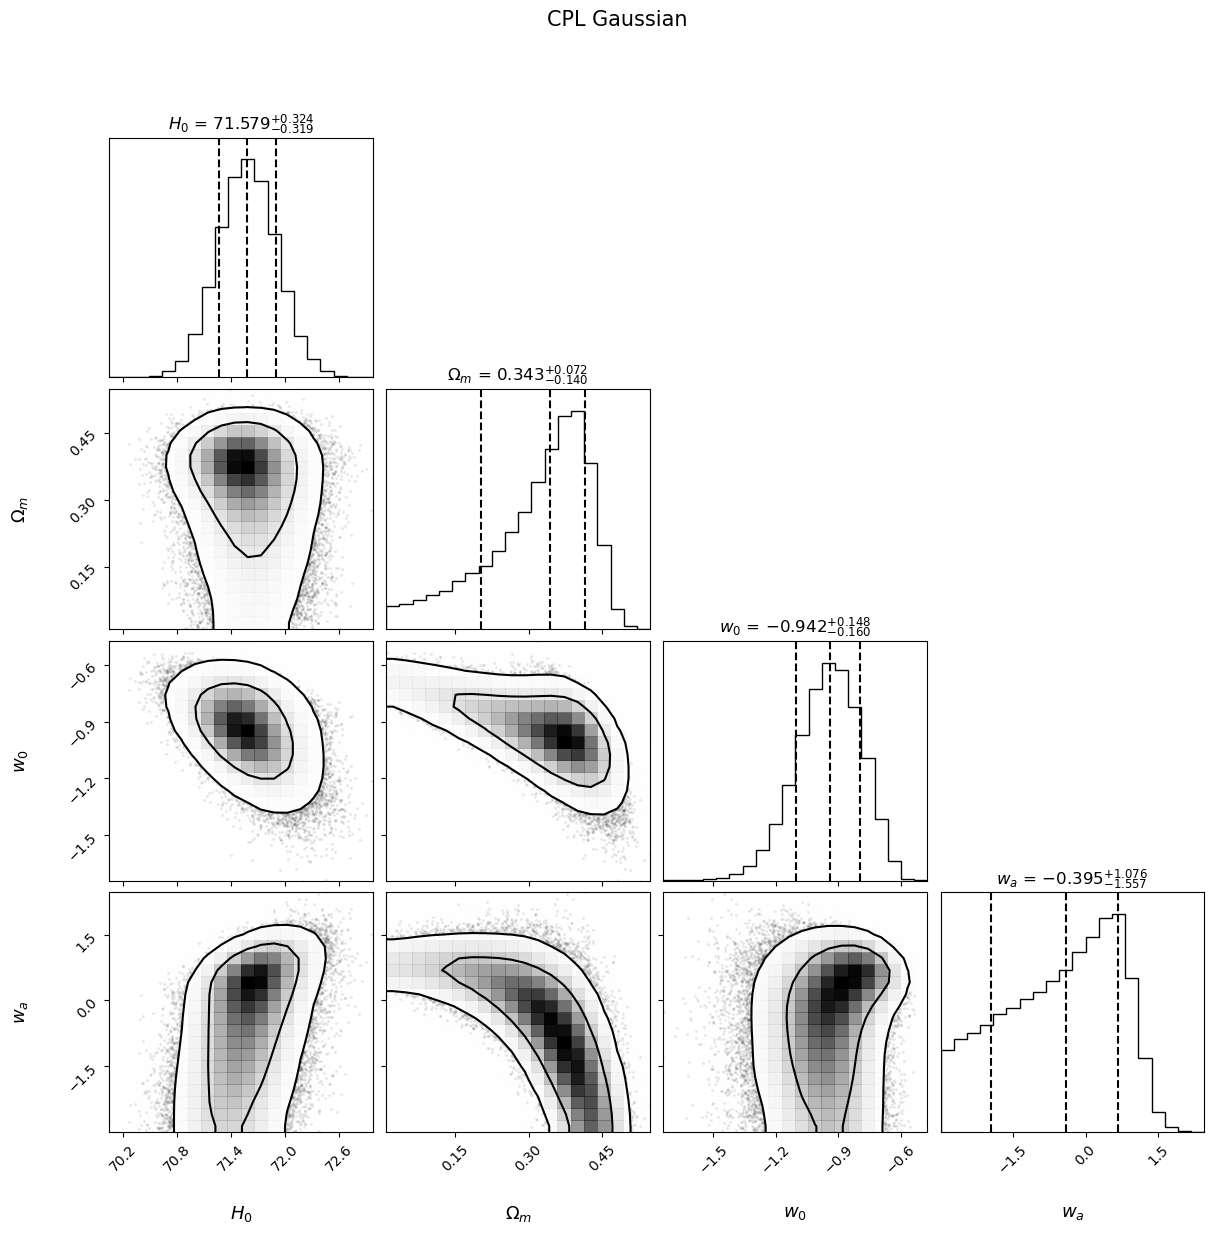


Running: CPL | Student's t
Initial guess: [71.6   0.32 -1.    0.   30.  ]
Initial log posterior: 895.1781413476089
Minimizer success: True
Best fit: [ 7.16006958e+01  3.01842296e-01 -9.32199001e-01  6.16239056e-03
  4.46745784e+00]
Best log posterior: 897.3405037924788


100%|█████████████████████████████████████| 10000/10000 [12:37<00:00, 13.21it/s]


Mean acceptance fraction: 0.3574739583333333


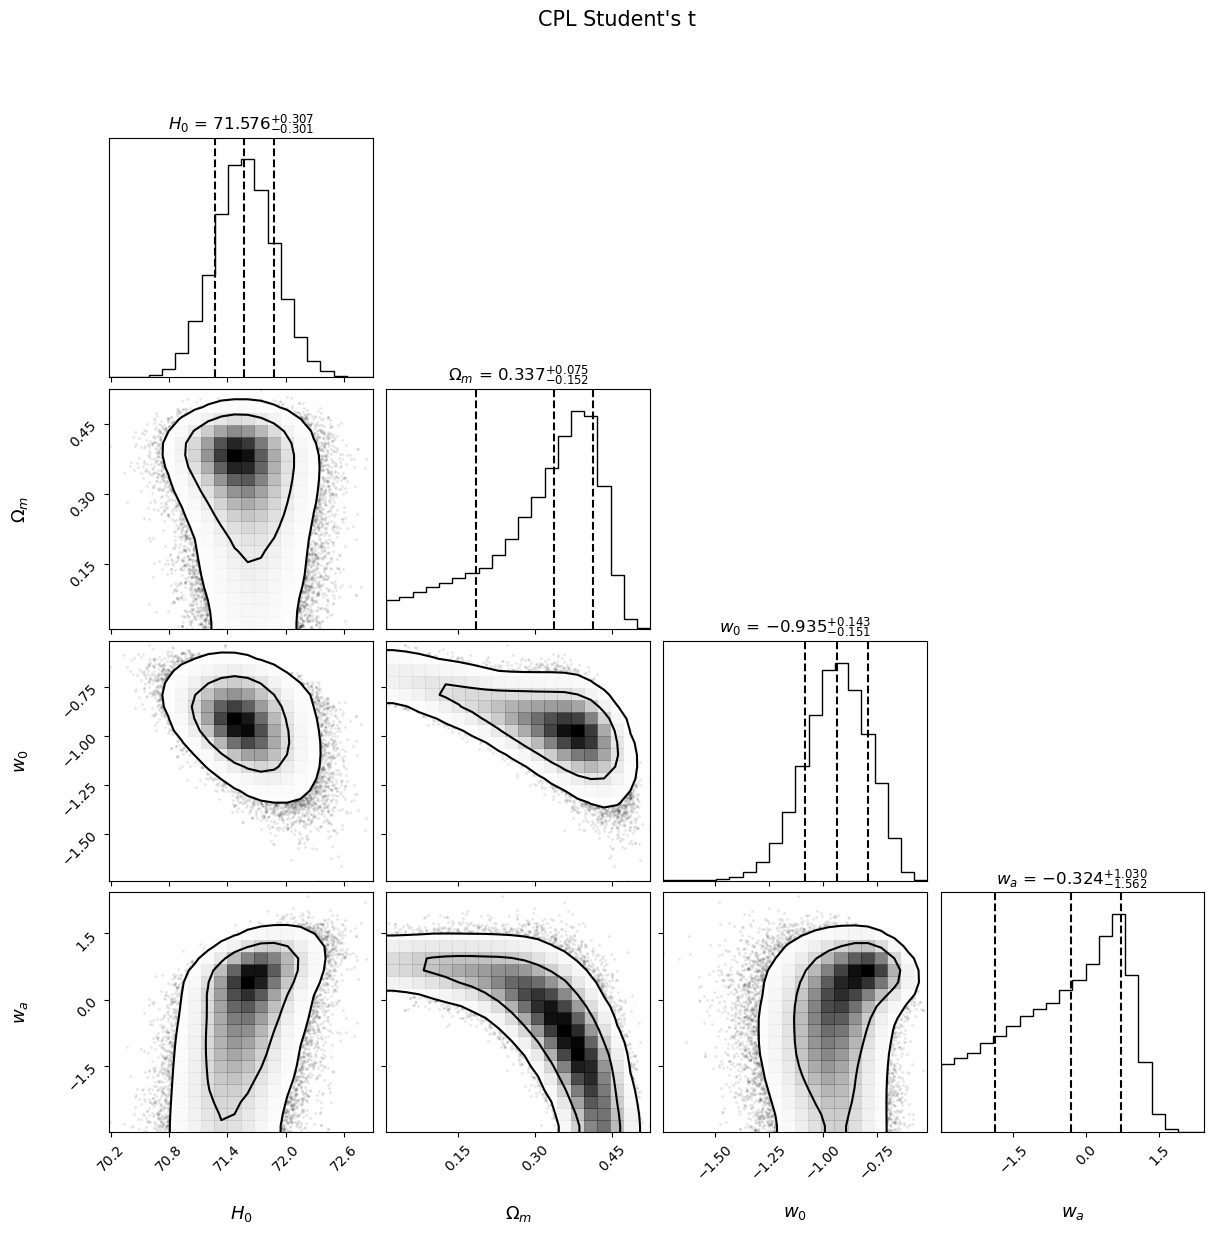

All plots saved in: pantheon_final_contours


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
import emcee
import os

from scipy.integrate import cumulative_trapezoid
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize
from scipy import special


# Basic constants
c = 299792.458
MB_FIXED = -19.3

outdir = "pantheon_final_contours"
os.makedirs(outdir, exist_ok=True)

np.random.seed(42)

DATA_FILE = "/Users/krp_21/Downloads/Data Analysis Project/DataRelease-main/Pantheon+_Data/4_DISTANCES_AND_COVAR/Pantheon+SH0ES.dat"

COV_FILE = "/Users/krp_21/Downloads/Data Analysis Project/DataRelease-main/Pantheon+_Data/4_DISTANCES_AND_COVAR/Pantheon+SH0ES_STAT+SYS.cov"


# Load Pantheon+ data
data = pd.read_csv(DATA_FILE, sep=r"\s+")

z_all = data["zHD"].values
mbcorr_all = data["m_b_corr"].values
is_cal_all = data["IS_CALIBRATOR"].astype(bool).values
cephdist_all = data["CEPH_DIST"].values

mask = (z_all > 0.01) | is_cal_all

z = z_all[mask]
mbcorr = mbcorr_all[mask]
is_cal = is_cal_all[mask]
cephdist = cephdist_all[mask]

N = len(z)

print("Number of supernovae used:", N)
print("Fixed MB:", MB_FIXED)


# Load covariance matrix
cov_raw = np.loadtxt(COV_FILE)

N_full = int(cov_raw[0])
cov_full = cov_raw[1:].reshape((N_full, N_full))

indices = np.where(mask)[0]
cov = cov_full[np.ix_(indices, indices)]

cho = cho_factor(cov, lower=True, check_finite=False)

signC, logdetC = np.linalg.slogdet(cov)

if signC <= 0:
    raise ValueError("Covariance matrix is not positive definite.")

print("Covariance matrix shape:", cov.shape)


# Redshift grid
z_grid = np.linspace(0.0, np.max(z) * 1.2, 6000)


def E_Flat_LCDM(zg, Om):
    # Flat LCDM expansion

    value = Om * (1.0 + zg)**3 + (1.0 - Om)

    if np.any(value <= 0):
        return None

    return np.sqrt(value)


def E_LCDM(zg, Om, Ok):
    # Non-flat LCDM expansion

    Ol = 1.0 - Om - Ok

    value = (
        Om * (1.0 + zg)**3
        + Ok * (1.0 + zg)**2
        + Ol
    )

    if np.any(value <= 0):
        return None

    return np.sqrt(value)


def E_wCDM(zg, Om, w):
    # Flat wCDM expansion

    value = (
        Om * (1.0 + zg)**3
        + (1.0 - Om) * (1.0 + zg)**(3.0 * (1.0 + w))
    )

    if np.any(value <= 0):
        return None

    return np.sqrt(value)


def E_CPL(zg, Om, w0, wa):
    # Flat CPL expansion

    value = (
        Om * (1.0 + zg)**3
        + (1.0 - Om)
        * (1.0 + zg)**(3.0 * (1.0 + w0 + wa))
        * np.exp(-3.0 * wa * zg / (1.0 + zg))
    )

    if np.any(value <= 0):
        return None

    return np.sqrt(value)


def luminosity_distance(theta, model):
    # Luminosity distance in Mpc

    if model == "Flat_LCDM":
        H0, Om = theta
        Ez = E_Flat_LCDM(z_grid, Om)
        Ok = 0.0

    elif model == "LCDM":
        H0, Om, Ok = theta
        Ez = E_LCDM(z_grid, Om, Ok)

    elif model == "wCDM":
        H0, Om, w = theta
        Ez = E_wCDM(z_grid, Om, w)
        Ok = 0.0

    elif model == "CPL":
        H0, Om, w0, wa = theta
        Ez = E_CPL(z_grid, Om, w0, wa)
        Ok = 0.0

    else:
        raise ValueError("Unknown model.")

    if Ez is None:
        return None

    if H0 <= 0:
        return None

    chi = cumulative_trapezoid(1.0 / Ez, z_grid, initial=0.0)

    DH = c / H0

    if abs(Ok) < 1e-8:
        DM_grid = DH * chi

    elif Ok > 0:
        sqrtOk = np.sqrt(Ok)
        DM_grid = DH / sqrtOk * np.sinh(sqrtOk * chi)

    else:
        sqrtAbsOk = np.sqrt(abs(Ok))
        DM_grid = DH / sqrtAbsOk * np.sin(sqrtAbsOk * chi)

    DL_grid = (1.0 + z_grid) * DM_grid

    DL = np.interp(z, z_grid, DL_grid)

    if np.any(DL <= 0) or np.any(~np.isfinite(DL)):
        return None

    return DL


def mu_model(theta, model):
    # Distance modulus

    DL = luminosity_distance(theta, model)

    if DL is None:
        return None

    mu = 5.0 * np.log10(DL) + 25.0

    if np.any(~np.isfinite(mu)):
        return None

    return mu


def compute_residual(theta, model):
    # Magnitude residual

    mu = mu_model(theta, model)

    if mu is None:
        return None

    m_model = np.zeros_like(mbcorr)

    m_model[~is_cal] = mu[~is_cal] + MB_FIXED
    m_model[is_cal] = cephdist[is_cal] + MB_FIXED

    residual = mbcorr - m_model

    return residual


def loglike_gaussian(theta, model):
    # Gaussian likelihood

    r = compute_residual(theta, model)

    if r is None:
        return -np.inf

    Cinv_r = cho_solve(cho, r, check_finite=False)
    chi2 = r @ Cinv_r

    if not np.isfinite(chi2):
        return -np.inf

    logL = -0.5 * (chi2 + logdetC + N * np.log(2.0 * np.pi))

    return logL


def loglike_student(theta, model):
    # Student's t likelihood

    base_theta = theta[:-1]
    nu = theta[-1]

    if nu <= 2.0:
        return -np.inf

    r = compute_residual(base_theta, model)

    if r is None:
        return -np.inf

    Cinv_r = cho_solve(cho, r, check_finite=False)
    Qc = r @ Cinv_r

    if not np.isfinite(Qc):
        return -np.inf

    Q = (nu / (nu - 2.0)) * Qc
    logdetSigma = logdetC + N * np.log((nu - 2.0) / nu)

    logL = (
        special.loggamma((nu + N) / 2.0)
        - special.loggamma(nu / 2.0)
        - (N / 2.0) * np.log(nu * np.pi)
        - 0.5 * logdetSigma
        - ((nu + N) / 2.0) * np.log(1.0 + Q / nu)
    )

    if not np.isfinite(logL):
        return -np.inf

    return logL


def log_prior(theta, model, student=False):
    # Model priors

    if model == "Flat_LCDM":
        H0, Om = theta[:2]

        if not (50.0 < H0 < 100.0):
            return -np.inf

        if not (0.01 < Om < 1.0):
            return -np.inf

    elif model == "LCDM":
        H0, Om, Ok = theta[:3]

        if not (50.0 < H0 < 100.0):
            return -np.inf

        if not (0.01 < Om < 1.0):
            return -np.inf

        if not (-0.5 < Ok < 0.5):
            return -np.inf

    elif model == "wCDM":
        H0, Om, w = theta[:3]

        if not (50.0 < H0 < 100.0):
            return -np.inf

        if not (0.01 < Om < 1.0):
            return -np.inf

        if not (-2.0 < w < 2.0):
            return -np.inf

    elif model == "CPL":
        H0, Om, w0, wa = theta[:4]

        if not (50.0 < H0 < 100.0):
            return -np.inf

        if not (0.01 < Om < 1.0):
            return -np.inf

        if not (-2.0 < w0 < 2.0):
            return -np.inf

        if not (-3.0 < wa < 3.0):
            return -np.inf

    else:
        raise ValueError("Unknown model.")

    if student:
        nu = theta[-1]

        if not (2.0 < nu < 1e6):
            return -np.inf

        return -np.log(nu)

    return 0.0


def log_posterior(theta, model, student=False):
    # Posterior probability

    lp = log_prior(theta, model, student)

    if not np.isfinite(lp):
        return -np.inf

    if student:
        ll = loglike_student(theta, model)
    else:
        ll = loglike_gaussian(theta, model)

    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


def initial_guess(model, student=False):
    # Initial values

    if model == "Flat_LCDM":
        theta = np.array([71.6, 0.33])

    elif model == "LCDM":
        theta = np.array([71.6, 0.30, 0.00])

    elif model == "wCDM":
        theta = np.array([71.6, 0.32, -1.0])

    elif model == "CPL":
        theta = np.array([71.6, 0.32, -1.0, 0.0])

    else:
        raise ValueError("Unknown model.")

    if student:
        theta = np.append(theta, 30.0)

    return theta


def find_best_fit(model, student=False):
    # Best-fit starting point

    x0 = initial_guess(model, student)

    print("Initial guess:", x0)
    print("Initial log posterior:", log_posterior(x0, model, student))

    if not np.isfinite(log_posterior(x0, model, student)):
        raise RuntimeError("Initial point gives invalid posterior.")

    def objective(theta):
        value = log_posterior(theta, model, student)

        if not np.isfinite(value):
            return 1e100

        return -value

    result = minimize(
        objective,
        x0,
        method="Nelder-Mead",
        options={
            "maxiter": 8000,
            "xatol": 1e-7,
            "fatol": 1e-7
        }
    )

    print("Minimizer success:", result.success)
    print("Best fit:", result.x)
    print("Best log posterior:", -result.fun)

    return result.x


def make_walkers(best, model, student=False, nwalkers=96):
    # Walker positions

    ndim = len(best)

    if model == "Flat_LCDM":
        scale = np.array([0.03, 0.003])

    elif model == "LCDM":
        scale = np.array([0.03, 0.006, 0.006])

    elif model == "wCDM":
        scale = np.array([0.03, 0.006, 0.015])

    elif model == "CPL":
        scale = np.array([0.03, 0.006, 0.025, 0.08])

    else:
        raise ValueError("Unknown model.")

    if student:
        scale = np.append(scale, 1.5)

    p0 = []

    while len(p0) < nwalkers:
        trial = best + scale * np.random.randn(ndim)

        if np.isfinite(log_posterior(trial, model, student)):
            p0.append(trial)

    return np.array(p0)


def run_mcmc(model, student=False, nsteps=5000, burnin=1000, thin=10):
    # Run MCMC

    print("\nRunning:", model, "|", "Student's t" if student else "Gaussian")

    best = find_best_fit(model, student)

    ndim = len(best)

    if model == "Flat_LCDM":
        nwalkers = 64

    elif model == "LCDM":
        nwalkers = 64

    elif model == "wCDM":
        nwalkers = 80

    elif model == "CPL":
        nwalkers = 96

    else:
        raise ValueError("Unknown model.")

    p0 = make_walkers(best, model, student, nwalkers=nwalkers)

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        lambda th: log_posterior(th, model, student)
    )

    sampler.run_mcmc(p0, nsteps, progress=True)

    acceptance = np.mean(sampler.acceptance_fraction)

    print("Mean acceptance fraction:", acceptance)

    if acceptance == 0:
        raise RuntimeError("MCMC failed because acceptance fraction is zero.")

    samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)

    return samples


labels_dict = {
    "Flat_LCDM": [r"$H_0$", r"$\Omega_m$"],
    "LCDM": [r"$H_0$", r"$\Omega_m$", r"$\Omega_k$"],
    "wCDM": [r"$H_0$", r"$\Omega_m$", r"$w$"],
    "CPL": [r"$H_0$", r"$\Omega_m$", r"$w_0$", r"$w_a$"]
}


def make_corner_plot(samples, labels, filename, title):
    # Corner plot

    ndim = len(labels)

    fig = plt.figure(figsize=(3.2 * ndim, 3.2 * ndim))

    fig = corner.corner(
        samples,
        labels=labels,
        fig=fig,
        show_titles=True,
        title_fmt=".3f",
        quantiles=[0.16, 0.50, 0.84],
        levels=(0.68, 0.95),
        smooth=1.0,
        label_kwargs={"fontsize": 13},
        title_kwargs={"fontsize": 12}
    )

    fig.subplots_adjust(top=0.88)
    fig.suptitle(title, fontsize=15, y=0.98)

    plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()


models = ["Flat_LCDM", "LCDM", "wCDM", "CPL"]


for model in models:

    labels = labels_dict[model]

    if model == "Flat_LCDM":
        nsteps_use = 5000
        burnin_use = 1000

    elif model == "LCDM":
        nsteps_use = 5000
        burnin_use = 1000

    elif model == "wCDM":
        nsteps_use = 8000
        burnin_use = 2000

    elif model == "CPL":
        nsteps_use = 10000
        burnin_use = 2500

    samples_g = run_mcmc(
        model,
        student=False,
        nsteps=nsteps_use,
        burnin=burnin_use,
        thin=10
    )

    make_corner_plot(
        samples_g,
        labels,
        f"{outdir}/{model}_Gaussian.pdf",
        f"{model} Gaussian"
    )

    samples_t = run_mcmc(
        model,
        student=True,
        nsteps=nsteps_use,
        burnin=burnin_use,
        thin=10
    )

    samples_t_no_nu = samples_t[:, :-1]

    make_corner_plot(
        samples_t_no_nu,
        labels,
        f"{outdir}/{model}_Students_t.pdf",
        f"{model} Student's t"
    )

print("All plots saved in:", outdir)